In [1]:
%pwd
%cd /home/jovyan/work/results/Cell/
%pwd

/home/jovyan/work/results/Cell


'/home/jovyan/work/results/Cell'

In [2]:
import scanpy as sc
import pandas as pd

In [3]:
df = pd.read_csv("NE_normalized_stages.csv", index_col=0)
df

,I,III,IV,4S,NA
leiden,,,,,
0,0.226223,0.480753,0.913252,0.369183,0.107051
1,0.775342,0.094098,0.104097,1.000000,0.019872
2,1.000000,0.084260,0.119232,0.378490,0.007692
3,0.101370,0.287853,0.753784,0.182006,0.058974
4,0.003914,1.000000,0.320413,0.002068,0.000641
...,...,...,...,...,...
74,0.007436,0.009410,0.048357,0.004137,0.000641
75,0.000000,0.000000,0.000000,0.000000,0.082692
76,0.000000,0.026518,0.000000,0.000000,0.000000


In [4]:
ndata = sc.read_h5ad("discrete_cancer_stages_annotated.h5ad")
ndata

AnnData object with n_obs × n_vars = 114874 × 12850
    obs: 'sample_source', 'sample_ID', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type', 'cell_cycle', 'Gender', 'Age', 'Shimada', 'INSS_stage', 'COG_risk_group', 'Distant_metastasis', 'NSE', 'LDH', 'MYCN-amp', 'Survival/Death', 'discrete_cancer_stage'
    var: 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'INSS_stage_colors', 'hvg', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'sample_ID_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    obsp: 'connectivities', 'distances'

In [5]:
df.iloc[0]

I      0.226223
III    0.480753
IV     0.913252
4S     0.369183
NA     0.107051
Name: 0, dtype: float64

In [6]:
type(df.iloc[0])

pandas.core.series.Series

In [7]:
df.iloc[0].loc["NA"]

0.107051282051282

In [8]:
for i in df.iloc[0]:
    print(i)
    print(type(i))

0.2262230919765166
<class 'float'>
0.4807527801539777
<class 'float'>
0.913252122554448
<class 'float'>
0.3691830403309203
<class 'float'>
0.107051282051282
<class 'float'>


In [9]:
continuous_stage_dict = {"NA": 0, "I": 1, "III": 3, "IV": 4, "4S": 1.5}
continuous_stage_dict

{'NA': 0, 'I': 1, 'III': 3, 'IV': 4, '4S': 1.5}

In [10]:
ndata.obs["leiden"]

Cell_barcode
T44_AAACCTGAGAGGTTGC.1    12
T44_AAACCTGAGAGTGAGA.1     1
T44_AAACCTGAGTGTACCT.1    51
T44_AAACCTGCAATGCCAT.1     5
T44_AAACCTGCAATGGATA.1     5
                          ..
T40_TTTGGTTAGCAATATG.1    23
T40_TTTGGTTAGTGGAGTC.1    20
T40_TTTGGTTCATAGTAAG.1    47
T40_TTTGTCAAGTCAATAG.1     0
T40_TTTGTCATCACTTATC.1    47
Name: leiden, Length: 114874, dtype: category
Categories (79, object): ['0', '1', '2', '3', ..., '75', '76', '77', '78']

In [11]:
ndata.obs["leiden"].iloc[0]

'12'

In [12]:
df.index

Int64Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
            17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
            34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
            51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
            68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78],
           dtype='int64', name='leiden')

In [13]:
continuous_cancer_stage_annotation_list = []
for i in range(len(ndata.obs_names)):
    sum = 0
    for j in df.loc[int(ndata.obs["leiden"].iloc[i])]:
        sum += j
    # print(sum)
    
    score = 0
    for j in df.loc[int(ndata.obs["leiden"].iloc[i])].index:
        # print(j)
        # print(df.loc[int(ndata.obs["leiden"].iloc[i])].loc[j])
        # print(continuous_stage_dict[j] * df.loc[int(ndata.obs["leiden"].iloc[i])].loc[j] / sum)
        score += continuous_stage_dict[j] * df.loc[int(ndata.obs["leiden"].iloc[i])].loc[j] / sum
    # print(score)
    
    continuous_cancer_stage_annotation_list.append(score)

print(continuous_cancer_stage_annotation_list[:20])

[1.5893275438904397, 1.491928895626583, 1.7985202889294567, 1.854885288034576, 1.854885288034576, 1.7631217587966566, 1.4821067128583212, 3.35351396122739, 3.4125372179668645, 1.5893275438904397, 3.08107234959334, 2.2705466389306985, 1.491928895626583, 2.802466056900965, 2.971591692924435, 2.867964400477237, 2.802466056900965, 2.0759838326544844, 1.4452291020635224, 1.852923671474481]


In [14]:
ndata.obs["continuous_cancer_stage"] = continuous_cancer_stage_annotation_list
ndata

AnnData object with n_obs × n_vars = 114874 × 12850
    obs: 'sample_source', 'sample_ID', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type', 'cell_cycle', 'Gender', 'Age', 'Shimada', 'INSS_stage', 'COG_risk_group', 'Distant_metastasis', 'NSE', 'LDH', 'MYCN-amp', 'Survival/Death', 'discrete_cancer_stage', 'continuous_cancer_stage'
    var: 'mt', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'INSS_stage_colors', 'hvg', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'sample_ID_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    obsp: 'connectivities', 'distances'

In [15]:
ndata.write("continuous_cancer_stages_annotated.h5ad")

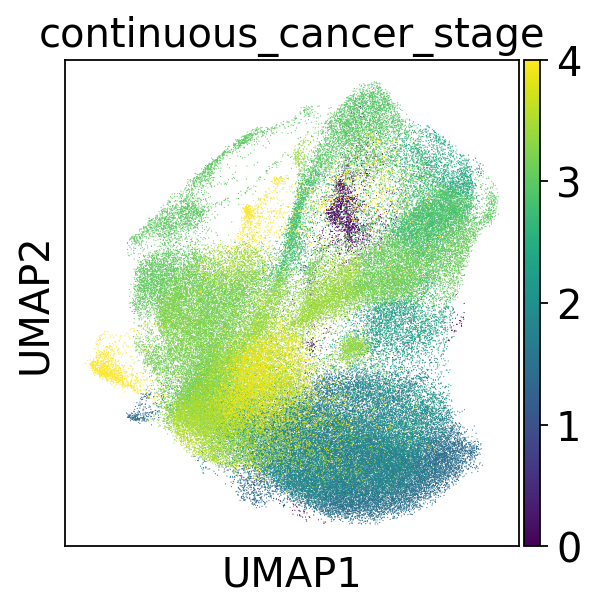

In [16]:
sc.set_figure_params(fontsize=18)
sc.pl.umap(ndata, color='continuous_cancer_stage', save="_NE_continuous_cancer_stage.pdf")